# Generate images and TI from the glacier image

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random
import csv


import tkinter as tk
from tkinter import filedialog

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\pysal\explore\segregation\network\network.py:16: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  "You need pandana and urbanaccess to work with segregation's network module\n"


Intro :
We define here the parameters, and the training image in which we will cut the data.

In [2]:
#Load the data
file_path = './data/TI/tif/ti_alti2_2016_2m.tif'
file_path_Mask = './data/Masks/tif/glacier_mask_2m.tif'

if os.path.isfile(file_path):
    print('Le fichier est présent. import')
    data_DEM = gr.from_file(file_path)
    (xmin, xsize, x, ymax, y, ysize) = data_DEM.geot

else:
    print('error')
    
if os.path.isfile(file_path_Mask):
    print('Le fichier est présent. import')
    data_Mask = gr.from_file(file_path_Mask)

else:
    print('error')
    
print('Sizes Infos :')

print(data_DEM.geot)
print(data_DEM.shape)
x_v = np.array(range(data_DEM.shape[1]))*data_DEM.geot[1] + data_DEM.geot[0]
y_v = np.array(range(data_DEM.shape[0]))*data_DEM.geot[5] + data_DEM.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)


Le fichier est présent. import
Le fichier est présent. import
Sizes Infos :
(583242.0, 2.0, 0.0, 131224.0, 0.0, -2.0)
(1557, 2967)


In [3]:
data_Mask.geot


(582190.2921000011, 2.0, 0.0, 131062.30120000157, 0.0, -2.0)

In [4]:


Hard_GPR = pd.read_csv('./data/PointSet/csv/bedRock_GPR.csv',delimiter =';')
Hard_MNT = pd.read_csv('./data/PointSet/csv/bedRock_MNT.csv',delimiter='\t')


Hard_pts = Hard_MNT.append(Hard_GPR[['X','Y','Bed_Alt']])
borders = [X_dem.min(),X_dem.max(),Y_dem.min(),Y_dem.max(), Hard_pts['X'].min(), Hard_pts['X'].max(),Hard_pts['Y'].min(), Hard_pts['Y'].max()]
x_min = min(borders[0],borders[4])
x_max = max(borders[1],borders[5])
y_min = min(borders[2],borders[6])
y_max = max(borders[3],borders[7])

nx = np.int(np.ceil((x_max - x_min)/2))
ny = np.int(np.ceil((y_max - y_min)/2))
referential = [x_min, y_max]
common_grid = np.ones([ny+1,nx+1])*np.min(data_DEM.raster)
Mask_com = np.zeros([ny+1,nx+1])
Hard_pts.insert(0,'Cell_x',(Hard_pts['X']-referential[0])/data_DEM.geot[1])
Hard_pts.insert(1,'Cell_y',(Hard_pts['Y']-referential[1])/data_DEM.geot[5])

In [5]:
referential_dem = np.round([data_DEM.geot[0]-referential[0], data_DEM.geot[3]-referential[1]])/2
 

In [6]:
common_grid[int(referential_dem[1]):int(referential_dem[1]+data_DEM.shape[0]) , int(referential_dem[0]):int(referential_dem[0]+data_DEM.shape[1])] = data_DEM.raster

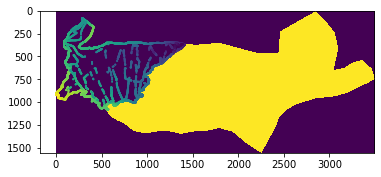

In [7]:
plt.imshow(common_grid)
plt.scatter(Hard_pts['Cell_x'],Hard_pts['Cell_y'], 1, Hard_pts['Bed_Alt'])


In [8]:
referential_mask = np.round([(data_Mask.geot[0]-referential[0])/data_Mask.geot[1], (data_Mask.geot[3]-referential[1])/data_Mask.geot[5]])
Mask_com[int(referential_mask[1]):int(referential_mask[1]+data_Mask.shape[0]) , int(referential_mask[0]):int(referential_mask[0]+data_Mask.shape[1])] = data_Mask.raster


In [9]:
Mask_f = Mask_com + (common_grid != np.min(common_grid))


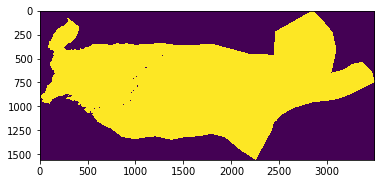

In [10]:
#plt.scatter(Hard_pts['Cell_x'],Hard_pts['Cell_y'], 1, Hard_pts['Bed_Alt'])
plt.imshow(Mask_f)
#plt.imshow(common_grid)

In [11]:
synthe_name = 'realisation' 
save_path = './real_data'
if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)



In [12]:
with open(save_path + '/' + synthe_name + str(1) + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx,0,ny], Hard_pts,common_grid,Mask_com], f, pickle.HIGHEST_PROTOCOL)
    
with open(save_path + '/' + synthe_name + str(2) + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx,0,ny], Hard_pts,common_grid,Mask_f], f, pickle.HIGHEST_PROTOCOL)